# Missing data

### What to do about holes, and what each repair costs you

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | The three missingness mechanisms and why the mechanism decides whether your fix is safe, what dropping rows silently costs, how mean filling shrinks a column and weakens every correlation it has, why a missingness indicator is often worth more than the imputed value, and why the imputer belongs inside the cross-validation fold |
| **You should already know** | [Cross-validation](../04-cross-validation/), [feature scaling and encoding](../07-feature-scaling-and-encoding/) |
| **Datasets** | California Housing, UCI Dry Bean |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [01-09 Hyperparameter tuning](../09-hyperparameter-tuning/) |

---

## 1. Why the mechanism decides everything

A missing value is not a value. Before you can replace it you have to decide what
its absence means, and there are three answers.

**Missing completely at random (MCAR).** The chance a value disappears has nothing
to do with anything: not the value itself, not any other column. A sensor drops a
reading because a cable was loose. The rows you keep are a smaller copy of the
rows you had.

**Missing at random (MAR).** The chance depends on things you *did* observe.
Districts with larger houses were surveyed by a different contractor who lost
income forms more often, and you have the room-count column. The name is a bad
one, because nothing here is random. It means *random once you condition on what
you can see*.

**Missing not at random (MNAR).** The chance depends on the missing value itself.
High earners decline to state their income. You cannot see what drove the absence,
because the thing that drove it is the thing that is gone.

That order decides what is recoverable. Under MCAR almost anything works. Under
MAR the information you need is sitting in the other columns, so an imputer that
reads those columns can get it back. Under MNAR the information is not in the file
at all, and no method invents it.

I am going to show this rather than assert it. Both house datasets arrive
complete, which is exactly what I want: I delete the values myself, so I know
every value I destroyed and can measure how far each repair lands from the truth.
On data that arrived broken you cannot do this, and that is why nobody ever shows
you the size of the damage.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

### One deletion function, three drivers

To compare the mechanisms fairly they have to lose the same number of values, so
I use a single deletion rule and change only what drives it. The probability of
deletion rises with a driver variable and averages to the rate I ask for, whatever
the driver is.

The driver is the mechanism. Random noise is MCAR. Another observed column is MAR.
The column itself is MNAR. Nothing else differs between the three.

In [2]:
X_full, y_full = datasets.california_housing()
COLUMN = "MedInc"
RATE = 0.30
COL_INDEX = list(X_full.columns).index(COLUMN)

rng = np.random.default_rng(SEED)


def deletion_mask(driver, rate, generator, floor=0.05):
    """True where the value gets deleted.

    Deletion probability climbs linearly with the rank of `driver`, from `floor`
    up to whatever keeps the average at `rate`. Ranks are used rather than raw
    values so a heavy tail in the driver cannot bend the overall rate.
    """
    ranks = pd.Series(np.asarray(driver)).rank(pct=True).to_numpy()
    probability = floor + 2.0 * (rate - floor) * ranks
    return generator.random(len(ranks)) < probability


drivers = {
    "MCAR": rng.normal(size=len(X_full)),      # pure noise, unrelated to the data
    "MAR": X_full["AveRooms"].to_numpy(),      # another column, and I still have it
    "MNAR": X_full[COLUMN].to_numpy(),         # the missing column itself
}

damaged, masks = {}, {}
for name, driver in drivers.items():
    mask = deletion_mask(driver, RATE, rng)
    frame = X_full.copy()
    frame[COLUMN] = frame[COLUMN].mask(mask)
    damaged[name], masks[name] = frame, mask
    print(f"{name:<5}: {mask.mean():.2%} of {COLUMN} deleted  "
          f"({mask.sum():,} of {len(mask):,} rows)")

print(f"\ncorrelation between {COLUMN} and the MAR driver AveRooms: "
      f"{X_full[COLUMN].corr(X_full['AveRooms']):+.3f}")
print("that correlation is what makes MAR partly recoverable later on")

MCAR : 30.14% of MedInc deleted  (6,221 of 20,640 rows)
MAR  : 30.38% of MedInc deleted  (6,271 of 20,640 rows)
MNAR : 30.19% of MedInc deleted  (6,231 of 20,640 rows)

correlation between MedInc and the MAR driver AveRooms: +0.327
that correlation is what makes MAR partly recoverable later on


### Which values disappeared

MCAR : survivors' mean 3.872  vs true mean 3.871
MAR  : survivors' mean 3.637  vs true mean 3.871
MNAR : survivors' mean 3.525  vs true mean 3.871


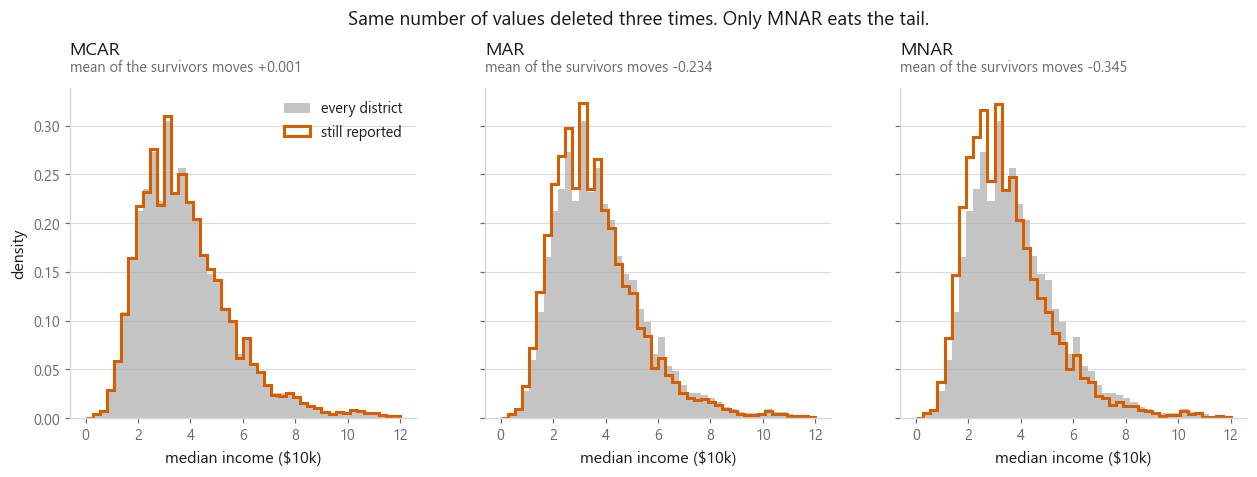

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.8, 3.9), sharey=True)
bins = np.linspace(0, 12, 45)

for ax, name in zip(axes, drivers):
    kept = ~masks[name]
    ax.hist(X_full[COLUMN], bins=bins, density=True, color=style.NEUTRAL,
            alpha=0.75, label="every district")
    ax.hist(X_full.loc[kept, COLUMN], bins=bins, density=True, histtype="step",
            color=style.HIGHLIGHT, lw=2.0, label="still reported")
    shift = X_full.loc[kept, COLUMN].mean() - X_full[COLUMN].mean()
    style.title(ax, name, f"mean of the survivors moves {shift:+.3f}")
    ax.set_xlabel("median income ($10k)")

axes[0].set_ylabel("density")
axes[0].legend(loc="upper right")
fig.suptitle("Same number of values deleted three times. Only MNAR eats the tail.",
             x=0.5, y=1.06, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-three-mechanisms.png")

for name in drivers:
    kept = ~masks[name]
    print(f"{name:<5}: survivors' mean {X_full.loc[kept, COLUMN].mean():.3f}  "
          f"vs true mean {X_full[COLUMN].mean():.3f}")

The grey shape is every district. The orange outline is the districts that still
report an income. Under MCAR the outline sits on top of the grey, because a random
subset of a distribution has the shape of the whole thing. Under MAR it drifts.
Under MNAR the right tail is gone, and no amount of care with the remaining rows
brings it back, because those rows never contained it.

### Now measure the damage

I fill the holes with the column mean and ask four questions. How far are the
filled values from the truth I deleted? How far is the column mean from the truth?
Are the model's predictions systematically off on the rows that lost a value? And
how much worse does the model get overall?

The mean rather than the median, because its arithmetic is exact and section 3
takes it apart. Under MCAR the filled column's mean is the observed mean, which is
the true mean, so any drift you see there came from the mechanism and nothing
else. The median behaves the same way for the same reasons.

For the model I damage the whole dataset before splitting, not just the training
half. That is the honest setup: if incomes go missing in your data, they will go
missing in the rows you predict on next month too. The imputer sits inside a
pipeline so it is refitted on each training fold, which is the rule section 5
measures the cost of breaking.

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline

folds = KFold(5, shuffle=True, random_state=SEED)


def mean_pipeline(**kwargs):
    return make_pipeline(SimpleImputer(strategy="mean", **kwargs), LinearRegression())


baseline_r2 = r2_score(y_full, cross_val_predict(LinearRegression(), X_full, y_full,
                                                 cv=folds))
baseline_coef = LinearRegression().fit(X_full, y_full).coef_[COL_INDEX]
truth = X_full[COLUMN].to_numpy()

records = []
for name in drivers:
    frame, mask = damaged[name], masks[name]
    filled = SimpleImputer(strategy="mean").fit_transform(frame)[:, COL_INDEX]

    # honest predictions: the imputer is refitted on each training fold
    predicted = cross_val_predict(mean_pipeline(), frame, y_full, cv=folds)
    fitted = mean_pipeline().fit(frame, y_full)

    records.append({
        "mechanism": name,
        "fill error": np.sqrt(np.mean((filled[mask] - truth[mask]) ** 2)),
        "mean bias": filled.mean() - truth.mean(),
        "pred bias": (predicted - y_full.to_numpy())[mask].mean(),
        "r2": r2_score(y_full, predicted),
        "coef": fitted[-1].coef_[COL_INDEX],
    })

damage = pd.DataFrame(records).set_index("mechanism")
damage["r2 lost"] = baseline_r2 - damage["r2"]
damage["coef error"] = damage["coef"] - baseline_coef

print(f"complete data: R2 {baseline_r2:.4f}, {COLUMN} coefficient {baseline_coef:.4f}\n")
print(damage[["fill error", "mean bias", "pred bias", "r2", "r2 lost", "coef", "coef error"]]
      .to_string(float_format=lambda v: f"{v:>9.4f}"))

complete data: R2 0.6037, MedInc coefficient 0.4367

           fill error  mean bias  pred bias        r2   r2 lost      coef  coef error
mechanism                                                                            
MCAR           1.8964     0.0013     0.0063    0.4990    0.1047    0.3030     -0.1337
MAR            2.2463    -0.2339    -0.0924    0.4748    0.1289    0.2747     -0.1619
MNAR           2.3202    -0.3452    -0.2141    0.4685    0.1352    0.2667     -0.1700


magnitude of each kind of damage, MCAR against MNAR
  fill error : MCAR  1.8964   MNAR  2.3202   (    1.2x)
  mean bias  : MCAR  0.0013   MNAR  0.3452   (  271.3x)
  pred bias  : MCAR  0.0063   MNAR  0.2141   (   33.7x)
  r2 lost    : MCAR  0.1047   MNAR  0.1352   (    1.3x)
  coef error : MCAR  0.1337   MNAR  0.1700   (    1.3x)


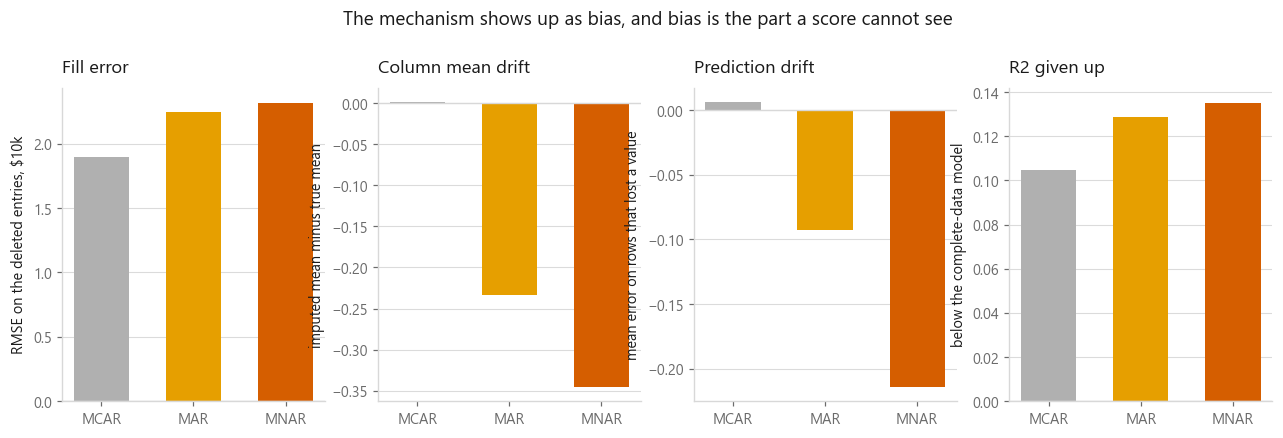

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14.2, 3.7))
names = list(damage.index)
positions = np.arange(len(names))
colours = [style.NEUTRAL, style.PALETTE[1], style.HIGHLIGHT]

panels = [
    ("fill error", "Fill error", "RMSE on the deleted entries, $10k"),
    ("mean bias", "Column mean drift", "imputed mean minus true mean"),
    ("pred bias", "Prediction drift", "mean error on rows that lost a value"),
    ("r2 lost", "R2 given up", "below the complete-data model"),
]
for ax, (field, headline, ylabel) in zip(axes, panels):
    ax.bar(positions, damage[field], color=colours, width=0.6)
    ax.set_xticks(positions, names)
    ax.set_ylabel(ylabel, fontsize=9.5)
    ax.axhline(0, color=style.RULE, lw=0.9)
    style.title(ax, headline)

fig.suptitle("The mechanism shows up as bias, and bias is the part a score cannot see",
             x=0.5, y=1.07, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-mechanism-damage.png")

print("magnitude of each kind of damage, MCAR against MNAR")
for field in ["fill error", "mean bias", "pred bias", "r2 lost", "coef error"]:
    mcar, mnar = abs(damage.loc["MCAR", field]), abs(damage.loc["MNAR", field])
    print(f"  {field:<11}: MCAR {mcar:>7.4f}   MNAR {mnar:>7.4f}   ({mnar / mcar:>7.1f}x)")

The same imputer, the same missing rate, the same column, three mechanisms, and
the four panels do not agree about how bad things are. That disagreement is the
lesson.

I expected the R2 panel to be the dramatic one, and it is the dullest. MCAR loses
a real amount of R2, because deleting a large share of the strongest predictor
destroys information whatever the reason for the deletion, and no imputer conjures
it back. MNAR loses more, but not by the margin I had in mind.

The bias panels are where the mechanism announces itself. Under MCAR the filled
column keeps roughly the right centre and the predictions on the affected rows are
off by roughly nothing on average, because the errors point both ways and cancel.
Under MNAR the column mean is dragged down and the predictions on exactly the rows
that lost a value are systematically too low, by a wide margin. Those rows are the
expensive districts, and the model will underprice them every time.

The coefficient says it a third way. Squashing every high income onto one number
flattens the relationship between income and price, so the model learns a weaker
slope than the one in the data.

So MCAR costs you information and MNAR costs you information plus a lie. A
cross-validation score prices the first and is blind to the second, which is why
the first thing to do with a column full of holes is not to pick an imputer. It is
to ask why the holes are there.

## 2. Dropping rows, and the arithmetic of the intersection

The tempting fix is `dropna()`. It has two costs, and the second one is the one
people are surprised by.

The first cost is arithmetic. If $k$ columns each independently lose a fraction
$p$ of their values, a row survives only if it dodged every one of them, so the
fraction of complete rows is $(1 - p)^k$. That falls off a cliff. Each column on
its own looks harmless; the intersection of a handful of harmless columns is not.

 columns    rate   measured    (1-p)^k
       1      5%     94.95%     95.00%
       1     10%     90.16%     90.00%
       1     20%     79.62%     80.00%
       2      5%     90.46%     90.25%
       2     10%     80.93%     81.00%
       2     20%     63.94%     64.00%
       4      5%     81.31%     81.45%
       4     10%     65.81%     65.61%
       4     20%     40.23%     40.96%
       8      5%     66.83%     66.34%
       8     10%     42.89%     43.05%
       8     20%     16.91%     16.78%
      16      5%     43.92%     44.01%
      16     10%     19.08%     18.53%
      16     20%      2.72%      2.81%


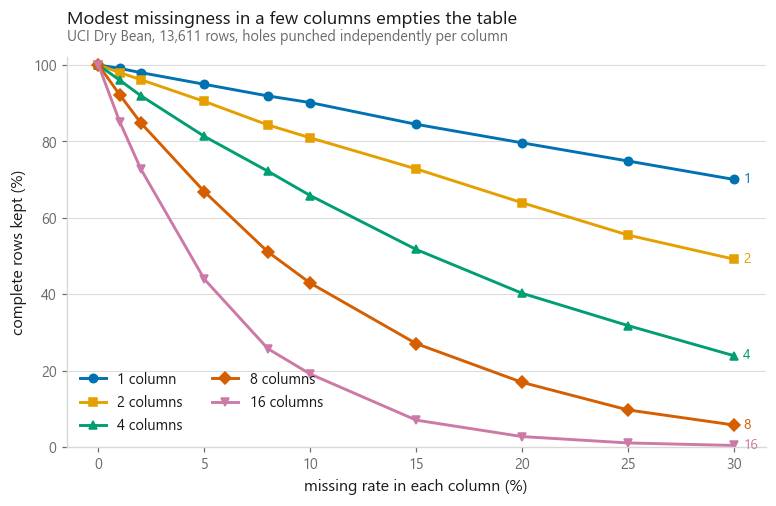

In [6]:
X_bean, _ = datasets.dry_bean()
bean_rng = np.random.default_rng(SEED)

rates = np.array([0.0, 0.01, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30])
column_counts = [1, 2, 4, 8, 16]

survival = {}
for k in column_counts:
    kept = []
    for p in rates:
        holes = bean_rng.random((len(X_bean), k)) < p
        kept.append((~holes.any(axis=1)).mean())
    survival[k] = np.array(kept)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
for i, k in enumerate(column_counts):
    ax.plot(rates * 100, survival[k] * 100, marker=style.MARKERS[i],
            color=style.PALETTE[i], label=f"{k} column{'s' if k > 1 else ''}")
    ax.annotate(f"{k}", xy=(rates[-1] * 100, survival[k][-1] * 100),
                xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=style.PALETTE[i])

ax.set_xlabel("missing rate in each column (%)")
ax.set_ylabel("complete rows kept (%)")
ax.set_ylim(0, 102)
ax.legend(loc="lower left", ncols=2)
style.title(ax, "Modest missingness in a few columns empties the table",
            "UCI Dry Bean, 13,611 rows, holes punched independently per column")
style.save(fig, FIG / "fig-03-rows-surviving.png")

print(f"{'columns':>8}  {'rate':>6}  {'measured':>9}  {'(1-p)^k':>9}")
for k in column_counts:
    for p, measured in zip(rates, survival[k]):
        if p in (0.05, 0.10, 0.20):
            print(f"{k:>8}  {p:>6.0%}  {measured:>9.2%}  {(1 - p) ** k:>9.2%}")

A rate you would call negligible in any single column stops being negligible once
the columns multiply, and the printed table says by how much. This is why "just
drop the incomplete rows" is a decision about sample size disguised as a decision
about tidiness, and why you should count the survivors before you commit.

The second cost is worse, because it is invisible. Dropping rows is only safe
under MCAR. Under MAR or MNAR the survivors are a biased sample, so every number
you compute afterwards is a number about a population that does not exist.

In [7]:
print(f"{'mechanism':<6}  {'rows kept':>10}  {'survivor mean':>14}  {'true mean':>10}  {'bias':>8}")
true_mean = X_full[COLUMN].mean()
for name in drivers:
    kept = ~masks[name]
    survivor_mean = X_full.loc[kept, COLUMN].mean()
    print(f"{name:<6}  {kept.mean():>10.1%}  {survivor_mean:>14.4f}  "
          f"{true_mean:>10.4f}  {survivor_mean - true_mean:>+8.4f}")

mechanism   rows kept   survivor mean   true mean      bias
MCAR         69.9%          3.8719      3.8707   +0.0013
MAR          69.6%          3.6368      3.8707   -0.2339
MNAR         69.8%          3.5254      3.8707   -0.3452


All three threw away about the same number of rows. Only one of them threw away a
random selection. Under MNAR the surviving districts are poorer than the real
ones, and the average income you would report from that table is simply wrong.

## 3. Simple imputation and what it distorts

Filling with the column mean is the default everyone reaches for, and it does
something specific that is easy to derive and easy to forget.

Say a fraction $p$ of the column is replaced by the mean of the observed part.
Those replaced entries now sit exactly at the centre, so they contribute nothing
to the spread. The variance of the column is multiplied by $1 - p$, and the
standard deviation by $\sqrt{1 - p}$.

The covariance with any other column shrinks by the same $1 - p$, because the
filled rows contribute a zero deviation to every product in the sum. Divide that
by the shrunken standard deviation and you get the result that matters:

$$\text{corr}_{\text{after}} \approx \sqrt{1 - p} \cdot \text{corr}_{\text{before}}$$

Every relationship the column had with every other column is weakened by the same
factor. The rows it touched come out wrong, and so does every relationship the
column has, including the one with your target.

In [8]:
truth_column = X_full[COLUMN]
mcar_column = damaged["MCAR"][COLUMN]
filled_column = mcar_column.fillna(mcar_column.mean())

others = pd.concat([X_full.drop(columns=COLUMN), y_full.rename("MedHouseVal")], axis=1)
corr_before = others.corrwith(truth_column)
corr_after = others.corrwith(filled_column)

actual_p = mcar_column.isna().mean()
shrink = np.sqrt(1 - actual_p)

# a correlation of almost zero divided by a correlation of almost zero is noise,
# so the ratio is only averaged over the relationships that were there to begin with
strong = corr_before.abs() > 0.05

print(f"missing fraction actually deleted : {actual_p:.4f}")
print(f"predicted shrink factor sqrt(1-p) : {shrink:.4f}\n")
print(f"standard deviation  {truth_column.std():.4f} -> {filled_column.std():.4f}"
      f"   (ratio {filled_column.std() / truth_column.std():.4f})")
print(f"correlation with target  {corr_before['MedHouseVal']:.4f} -> "
      f"{corr_after['MedHouseVal']:.4f}   (ratio "
      f"{corr_after['MedHouseVal'] / corr_before['MedHouseVal']:.4f})")
print(f"\nmean ratio across the {strong.sum()} correlations above 0.05 in magnitude: "
      f"{(corr_after[strong] / corr_before[strong]).mean():.4f}")

missing fraction actually deleted : 0.3014
predicted shrink factor sqrt(1-p) : 0.8358

standard deviation  1.8998 -> 1.5891   (ratio 0.8365)
correlation with target  0.6881 -> 0.5760   (ratio 0.8371)

mean ratio across the 5 correlations above 0.05 in magnitude: 0.8100


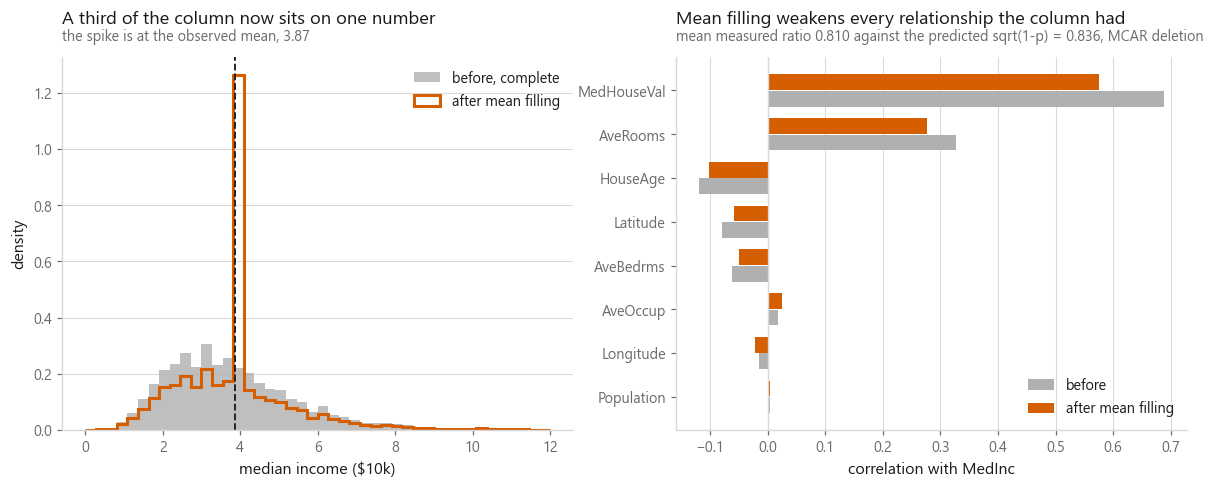

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.4))

axes[0].hist(truth_column, bins=bins, density=True, color=style.NEUTRAL,
             alpha=0.8, label="before, complete")
axes[0].hist(filled_column, bins=bins, density=True, histtype="step",
             color=style.HIGHLIGHT, lw=2.0, label="after mean filling")
axes[0].axvline(mcar_column.mean(), color=style.INK, ls="--", lw=1.2)
axes[0].set_xlabel("median income ($10k)")
axes[0].set_ylabel("density")
axes[0].legend(loc="upper right")
style.title(axes[0], "A third of the column now sits on one number",
            f"the spike is at the observed mean, {mcar_column.mean():.2f}")

order = list(corr_before.abs().sort_values().index)
pos = np.arange(len(order))
axes[1].barh(pos - 0.19, corr_before[order], height=0.36,
             color=style.NEUTRAL, label="before")
axes[1].barh(pos + 0.19, corr_after[order], height=0.36,
             color=style.HIGHLIGHT, label="after mean filling")
axes[1].set_yticks(pos, order)
axes[1].axvline(0, color=style.RULE, lw=0.9)
axes[1].set_xlabel(f"correlation with {COLUMN}")
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", visible=True)
axes[1].legend(loc="lower right")
style.title(axes[1], "Mean filling weakens every relationship the column had",
            f"mean measured ratio {(corr_after[strong] / corr_before[strong]).mean():.3f}"
            f" against the predicted sqrt(1-p) = {shrink:.3f}, MCAR deletion")

style.save(fig, FIG / "fig-04-mean-imputation.png")

The standard deviation and the correlation with the target both land on the
predicted $\sqrt{1 - p}$ to three decimals, and those are the two numbers the
derivation actually promised. Treat that as a planning tool: before you fill a
column, you already know how much of its relationship with the target you are
about to give away.

The average across every other column is the noisier number, and the chart's
subtitle prints it next to the prediction so you can see how far it sits. The
reason it is noisy is division. A correlation that started near zero, divided by
another correlation near zero, is noise with a ratio attached, and averaging a few
of those in drags the summary around. That is why the printed average is taken
only over the relationships that were there to begin with, and why I would apply
the formula to a column I already know matters rather than to a whole correlation
matrix at once.

The median behaves the same way for the same reason. Anything that replaces
missing values with one constant collapses their spread to zero.

This is also why you should be suspicious of a correlation matrix computed after
imputation, and why "the feature turned out to be unimportant" is a claim worth
checking against the missing rate of that feature.

## 4. Indicators, iterative and KNN imputation compared

### The cheapest thing that works

Add a column saying whether the value was missing. That is it. Under MNAR the
indicator carries the exact signal the imputed number destroyed, because the fact
of the absence *is* the information. `SimpleImputer(add_indicator=True)` does it
inside the pipeline, which keeps it honest across folds.

complete-data R2: 0.6037

            r2 plain  bias plain  r2 flagged  bias flagged    r2 gain
mechanism                                                            
MCAR          0.4990      0.0063      0.4990        0.0000    -0.0001
MAR           0.4748     -0.0924      0.4780       -0.0001     0.0032
MNAR          0.4685     -0.2141      0.4850       -0.0004     0.0166



R2 gain from adding the flag
  MCAR : -0.0001
  MAR  : +0.0032
  MNAR : +0.0166


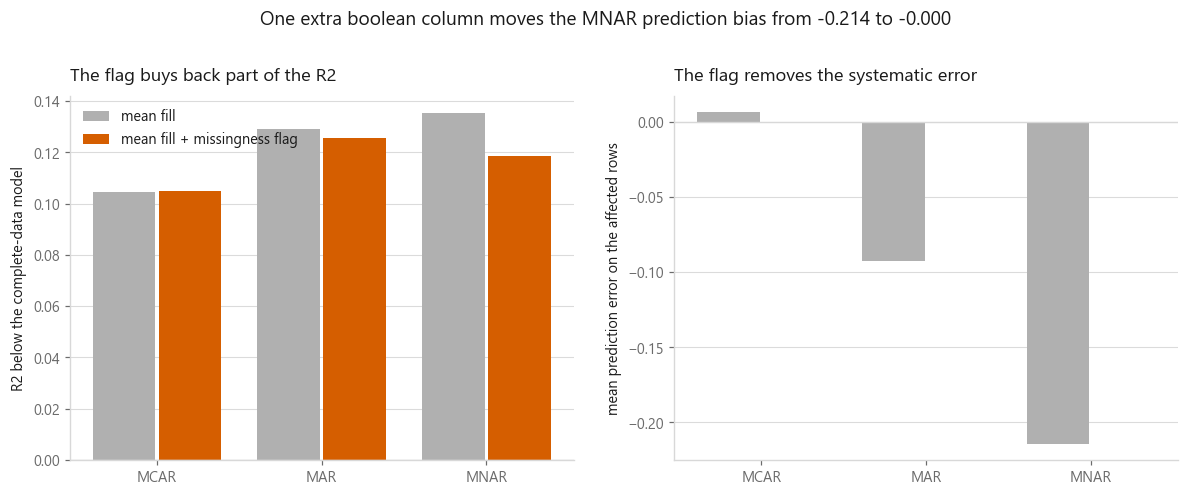

In [10]:
indicator_rows = []
for name in drivers:
    frame, mask = damaged[name], masks[name]
    row = {"mechanism": name}
    for label, model in [("plain", mean_pipeline()),
                         ("flagged", mean_pipeline(add_indicator=True))]:
        predicted = cross_val_predict(model, frame, y_full, cv=folds)
        row[f"r2 {label}"] = r2_score(y_full, predicted)
        row[f"bias {label}"] = (predicted - y_full.to_numpy())[mask].mean()
    row["r2 gain"] = row["r2 flagged"] - row["r2 plain"]
    indicator_rows.append(row)

indicators = pd.DataFrame(indicator_rows).set_index("mechanism")
print(f"complete-data R2: {baseline_r2:.4f}\n")
print(indicators.to_string(float_format=lambda v: f"{v:>10.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.3))
positions = np.arange(len(indicators))

pairs = [
    (axes[0], baseline_r2 - indicators["r2 plain"],
     baseline_r2 - indicators["r2 flagged"],
     "The flag buys back part of the R2", "R2 below the complete-data model"),
    (axes[1], indicators["bias plain"], indicators["bias flagged"],
     "The flag removes the systematic error",
     "mean prediction error on the affected rows"),
]
for ax, plain, flagged, headline, ylabel in pairs:
    ax.bar(positions - 0.2, plain, width=0.38, color=style.NEUTRAL,
           label="mean fill")
    ax.bar(positions + 0.2, flagged, width=0.38, color=style.HIGHLIGHT,
           label="mean fill + missingness flag")
    ax.set_xticks(positions, list(indicators.index))
    ax.set_ylabel(ylabel, fontsize=9.5)
    ax.axhline(0, color=style.RULE, lw=0.9)
    style.title(ax, headline)

axes[0].legend(loc="upper left")
fig.suptitle(f"One extra boolean column moves the MNAR prediction bias from "
             f"{indicators.loc['MNAR', 'bias plain']:+.3f} to "
             f"{indicators.loc['MNAR', 'bias flagged']:+.3f}",
             x=0.5, y=1.06, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-05-indicator-gain.png")

print("\nR2 gain from adding the flag")
for name in indicators.index:
    print(f"  {name:<5}: {indicators.loc[name, 'r2 gain']:+.4f}")

Under MCAR the flag is a column of noise and buys nothing, which is what it should
do. Under MNAR it buys back a real slice of the R2, and the right-hand panel is
the part I care about more: the prediction bias on the affected rows collapses to
near zero. A linear model with a dummy for "this row lost its income" can shift
those rows back up, which is precisely the correction a single filled constant
made impossible.

Under MAR the gain is small, and the reason is worth stating: the flag there is a
noisy copy of `AveRooms`, and `AveRooms` is already a feature. That information
was never lost, so there is nothing to recover.

The flag costs one column and no thought. I add it by default on any column where
I do not already know the mechanism is MCAR.

### Imputers that read the other columns

`IterativeImputer` models each column with holes as a regression on the other
columns and cycles until the filled values settle. It is still experimental in
scikit-learn, so it needs an explicit opt-in import before it can be used.
`KNNImputer` finds the nearest complete-enough rows and averages their values.

Both are slower than a constant, so I run this part on a subsample. Both also
measure distances or fit regressions across columns, which means the columns have
to be on comparable scales first. Without a scaler `Population` would drown
`Latitude` in every distance computation.

What I expect: under MAR these should beat the median clearly, because the
information sits in `AveRooms` and a regression can read it. Under MNAR they
should fail alongside the median, because the information is not in the file.

In [11]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (must come first)
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.preprocessing import StandardScaler

N_SUB = 3000
sub = rng.choice(len(X_full), N_SUB, replace=False)
X_sub_full = X_full.iloc[sub].reset_index(drop=True)
y_sub = y_full.iloc[sub].reset_index(drop=True)
sub_frames = {n: damaged[n].iloc[sub].reset_index(drop=True) for n in drivers}
sub_masks = {n: masks[n][sub] for n in drivers}
sub_folds = KFold(3, shuffle=True, random_state=SEED)

sub_baseline = cross_val_score(make_pipeline(StandardScaler(), LinearRegression()),
                               X_sub_full, y_sub, cv=sub_folds, scoring="r2").mean()


def filled_in_original_units(frame, imputer):
    """Scale, impute, and undo the scaling so errors stay in $10k."""
    scaler = StandardScaler().fit(frame)          # StandardScaler ignores NaN
    out = imputer.fit_transform(scaler.transform(frame))
    return scaler.inverse_transform(out[:, :frame.shape[1]])


candidates = {
    "mean": lambda: SimpleImputer(strategy="mean"),
    "median": lambda: SimpleImputer(strategy="median"),
    "median + indicator": lambda: SimpleImputer(strategy="median", add_indicator=True),
    "KNN (k=5)": lambda: KNNImputer(n_neighbors=5),
    "iterative": lambda: IterativeImputer(max_iter=10, random_state=SEED),
}

truth_sub = X_sub_full[COLUMN].to_numpy()
comparison = []
for name in drivers:
    frame, mask = sub_frames[name], sub_masks[name]
    for label, factory in candidates.items():
        guess = filled_in_original_units(frame, factory())[:, COL_INDEX]
        score = cross_val_score(
            make_pipeline(StandardScaler(), factory(), LinearRegression()),
            frame, y_sub, cv=sub_folds, scoring="r2").mean()
        comparison.append({
            "mechanism": name, "imputer": label,
            "fill error": np.sqrt(np.mean((guess[mask] - truth_sub[mask]) ** 2)),
            "mean bias": guess.mean() - truth_sub.mean(),
            "r2": score, "r2 lost": sub_baseline - score,
        })

table = pd.DataFrame(comparison).set_index(["mechanism", "imputer"])
print(f"subsample of {N_SUB:,} rows, 3-fold, complete-data R2 {sub_baseline:.4f}\n")
print(table.to_string(float_format=lambda v: f"{v:>9.4f}"))

subsample of 3,000 rows, 3-fold, complete-data R2 -4.3744

                              fill error  mean bias        r2   r2 lost
mechanism imputer                                                      
MCAR      mean                    1.7974     0.0125   -5.9481    1.5738
          median                  1.8313    -0.1028   -6.0211    1.6467
          median + indicator      1.8313    -0.1028   -5.9594    1.5850
          KNN (k=5)               1.0938     0.0156   -4.4878    0.1134
          iterative               1.0976    -0.0045   -4.9888    0.6144
MAR       mean                    2.1741    -0.2030   -5.8234    1.4490
          median                  2.3019    -0.3102   -5.9230    1.5486
          median + indicator      2.3019    -0.3102   -5.7576    1.3832
          KNN (k=5)               1.1772    -0.0205   -4.3571   -0.0173
          iterative               1.2453    -0.0035   -4.7165    0.3422
MNAR      mean                    2.3259    -0.3443   -5.9712    1.5968
     

Read the line above the table first, because it decides how to read everything
under it. The complete-data R2 on this subsample is negative. A plain linear
regression on three thousand rows across three folds is failing outright here,
worse than predicting the mean, which the full-data version in section 1 never
did. Every R2 in the block below it is negative as well, and `r2 lost` is
therefore a distance from a broken reference rather than from a working one. The
likely culprit is the handful of California districts with absurd `AveOccup`
values: on a subsample this size, one of them landing in a validation fold
produces a single prediction wild enough to swamp the fold. Differences down a
column are still meaningful, because the same baseline is subtracted from every
row. The level is not. I would not quote any single number out of that column.

Now the `fill error` column, read down each mechanism block. Under MCAR and MAR
the imputers that read other columns beat the constants at guessing the value that
was deleted, and by a wide margin, because median income is genuinely predictable
from rooms, location and occupancy. Under MNAR that stops being a rule. KNN still
guesses closer than the median does, while `IterativeImputer` turns in the worst
fill error anywhere in the table — worse than the median it was supposed to
improve on, and not by a little. Regressing the missing column on the others,
feeding those guesses back in and iterating, is a loop with nothing to anchor it
once the top of the column has been deleted, and it walks away from the truth
instead of toward it.

The `mean bias` column then contradicts the thing I expected to write. I assumed
the bias would survive every method under MNAR, because the tail is gone from the
file and no method invents it. It does not survive. The constants carry the full
drift, and both column-reading imputers cut it to a fraction of that. They cannot
see the deleted incomes, but they can see that a district with those rooms, that
occupancy and that location ought to earn more than the surviving average, and
that is enough to push part of the tail back.

The `r2 lost` column settles it, and not in the direction I had in mind. On the
MNAR block KNN is the clear winner on the shipped score and the median with an
indicator is nowhere near it — the gap between those two is wider in `r2 lost`
than it is in `fill error`, not narrower. So the comfortable story, that a cheap
constant plus a flag buys you most of what an expensive imputer buys, is not what
this table says. What survives of it is narrower: a downstream model tolerates
imprecision in individual filled values far better than it tolerates a systematic
shift, and here the methods that removed the shift are the methods that won.

My rule from this: measure, and do not assume which end of the table wins. Start
with the median and an indicator because it costs one argument, run KNN alongside
it, and be ready for the iterative imputer to come last rather than first.

## 5. Imputing inside the fold

The imputer learns from data. A mean is a statistic, a KNN pool is the whole
training set, an iterative imputer is a stack of fitted regressions. Any of those
fitted before the split has seen the rows you are about to score on, and your
validation number is then partly a number about itself.

The size of the leak depends on how much the imputer learns and how little data it
has. With a column mean on a large table it is nothing. With a KNN imputer on a
small sample it is real, so that is where I measure it.

The comparison is paired: the same subsample, the same folds, the same model. Only
the placement of the cleaning step changes.

In [12]:
from sklearn.linear_model import Ridge

N_SMALL, LEAK_RATE, REPEATS = 150, 0.40, 60
leak_rng = np.random.default_rng(SEED + 1)


def leakage_gap(factory, repeats=REPEATS):
    """Score reported when cleaning happens before the split, minus the honest one."""
    gaps = []
    for trial in range(repeats):
        idx = leak_rng.choice(len(X_full), N_SMALL, replace=False)
        Xs = X_full.iloc[idx].reset_index(drop=True)
        ys = y_full.iloc[idx].reset_index(drop=True)
        for column in Xs.columns[:4]:                       # MCAR holes in four columns
            Xs[column] = Xs[column].mask(leak_rng.random(N_SMALL) < LEAK_RATE)

        cv = KFold(5, shuffle=True, random_state=trial)
        honest = cross_val_score(
            make_pipeline(StandardScaler(), factory(), Ridge()),
            Xs, ys, cv=cv, scoring="r2").mean()

        cleaned = make_pipeline(StandardScaler(), factory()).fit_transform(Xs)
        leaky = cross_val_score(Ridge(), cleaned, ys, cv=cv, scoring="r2").mean()
        gaps.append(leaky - honest)
    return np.array(gaps)


for label in ["mean", "KNN (k=5)"]:
    gaps = leakage_gap(candidates[label])
    print(f"{label:<10}: leaky minus honest R2 = {gaps.mean():+.4f}  "
          f"(higher in {np.mean(gaps > 0):.0%} of {REPEATS} repeats)")

mean      : leaky minus honest R2 = +0.1487  (higher in 72% of 60 repeats)


KNN (k=5) : leaky minus honest R2 = +1.2226  (higher in 70% of 60 repeats)


I wrote this section expecting to report a rounding error and then argue the rule
on principle. Neither printed gap is a rounding error. The KNN gap is larger than
the entire R2 of plenty of perfectly respectable models, and even the column mean
— the least ambitious imputer there is — moves the reported score by an amount
anyone would happily write up as an improvement.

KNN leaks hardest for a mechanical reason. Fitted on everything, a held-out row
gets filled from its own neighbours inside the held-out set, so part of the row
you are about to score was reconstructed out of the answer. The mean leaks less,
because a mean over the whole sample is close to a mean over four fifths of it,
but less is not none, and on a sample this small the difference is visible.

The conditions here are deliberately harsh: few rows, a high missing rate, and
holes in four columns at once. That is the point of them. Those are the conditions
under which people skip the pipeline, and the damage does not announce itself as
an error. It shows up as a model selection that drifts toward whichever imputer
leaks hardest, and a reported score that is quietly too high.

Now the same question on the full dataset, where there is plenty of data and the
imputer is simple.

In [13]:
full_honest = cross_val_score(mean_pipeline(), damaged["MCAR"], y_full,
                              cv=folds, scoring="r2").mean()
full_cleaned = SimpleImputer(strategy="mean").fit_transform(damaged["MCAR"])
full_leaky = cross_val_score(LinearRegression(), full_cleaned, y_full,
                             cv=folds, scoring="r2").mean()

print(f"honest (imputer inside the fold) : {full_honest:.6f}")
print(f"leaky  (imputed before the split): {full_leaky:.6f}")
print(f"difference                       : {full_leaky - full_honest:+.6f}")
print(f"\nrows: {len(X_full):,}")

honest (imputer inside the fold) : 0.498965
leaky  (imputed before the split): 0.498961
difference                       : -0.000004

rows: 20,640


On a table this size with a column mean it is invisible, and someone will use that
to argue the rule does not matter. The rule still matters, because the same code
path runs on your next dataset, which will be smaller, and with your next imputer,
which will be cleverer. `Pipeline` costs nothing and removes the question.

## Cheat sheet

| | |
|---|---|
| **First question** | Why is it missing? MCAR, MAR or MNAR decides everything that follows. Ask the people who collected the data |
| **MCAR** | Any method works. Dropping rows is unbiased, it just costs sample size |
| **MAR** | Constants are biased. An imputer that reads the other columns can recover it, because the driver is a column you still have |
| **MNAR** | The driver is gone, so nothing recovers it in full. An imputer that reads the other columns still removes a good part of the bias, because the surviving columns know roughly what the missing one should have said. Add a missingness indicator, say so in writing, and stop pretending the number you filled in is a measurement |
| **Dropping rows** | $k$ columns at rate $p$ leaves $(1-p)^k$ of the table. Count the survivors before you commit, and remember they are a random sample only under MCAR |
| **Mean or median fill** | Multiplies the column's variance by $1-p$ and every correlation it has by $\sqrt{1-p}$. Fast, unbiased under MCAR, and it flattens the column |
| **Missingness indicator** | One boolean column, near-zero cost, often worth more than the filled value under MNAR. `SimpleImputer(add_indicator=True)` |
| **IterativeImputer** | Needs `from sklearn.experimental import enable_iterative_imputer` first. Competitive under MCAR and MAR, and the worst method in the table under MNAR, where its refitting loop has nothing to anchor it. Noticeably slower. Check it, do not assume it |
| **KNNImputer** | Scale first or the widest column decides every distance. Costs $O(n^2)$ in the fit. Best method in the comparison here, including on the MNAR block where I expected it to fail |
| **Always** | Imputer inside the `Pipeline`, so it refits on each training fold |
| **Next** | [Hyperparameter tuning](../09-hyperparameter-tuning/), where the same inside-the-fold rule decides whether your search result is real |

## What to remember

1. The mechanism, not the method, decides whether a fix is safe. MCAR forgives
   everything, MAR is recoverable from the columns you kept, MNAR is not
   recoverable at all.
2. `dropna()` on several columns at once is a decision about sample size. The
   complete fraction is $(1-p)^k$ and it collapses faster than anyone expects.
3. Filling with a constant shrinks the column's variance by $1-p$ and weakens
   every correlation it has by $\sqrt{1-p}$, including the one with your target.
4. A missingness indicator is one boolean column and frequently recovers more than
   a better guess at the value would.
5. Fill accuracy and shipped score are different rankings, and neither one implies
   the other. In the comparison here KNN won both, the iterative imputer won
   neither under MNAR, and the cheap constant plus a flag did not hold its own.
   Run all three on your own data rather than reasoning about which should win.
6. Fit the imputer inside the cross-validation fold. On a small sample with a
   learned imputer the leak was worth more R2 than most models have to give.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [01-09 Hyperparameter tuning](../09-hyperparameter-tuning/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#MissingData` `#Imputation` `#MCAR` `#MNAR`
`#DataCleaning` `#Python` `#ScikitLearn` `#DataScience` `#MLTutorial`